## Community Detection

### Uvod

Ako centralnost (bilježnica 02) pita "tko je važan?", otkrivanje zajednica pita "koje destinacije se prirodno grupiraju zajedno?". Ova bilježnica koristi Louvainovu maksimizaciju modularnosti kao primarni algoritam, uspoređuje je s Girvan-Newman algoritmom te eksterno validira otkrivene zajednice u odnosu na stvarnu (ground-truth) oznaku obalno/kontinentalno.

### Istraživački cilj

Testirati hipotezu da se mreža sličnosti sezonalnosti organizira u (barem) dvije velike zajednice koje odgovaraju obalnim i kontinentalnim destinacijama, te kvantificirati koliko čisto ta podjela vrijedi.



In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from src.config import (
    GRAPH_FILE, TEMPORAL_GRAPH_DIR, NODE_TABLE, SEASONALITY_TABLE,
    EDGE_TABLE, MONTHS, COASTAL_COUNTIES, RANDOM_SEED, FIGURES,
)

from src import community_detection as cd, viz

g = nx.read_graphml(GRAPH_FILE)
print(g.number_of_nodes(), 'nodes,', g.number_of_edges(), 'edges')

554 nodes, 3691 edges


## Louvain partition

In [2]:
partition = cd.louvain_partition(g)
df = cd.partition_to_frame(g, partition)
q = cd.modularity(g, partition)
print('Modularity Q =', round(q, 4))
print('Communities found:', df['community'].nunique())
df.head(10)

Modularity Q = 0.6969
Communities found: 210


,region,community,coastal
0,Andrijasevci,0,False
1,Antunovac,1,False
2,Babina Greda,2,False
3,Bakar,21,True
4,Bale - Valle,5,True
5,Barban,5,True
6,Barilovic,5,False
7,Baska,6,True
8,Baska Voda,5,True
9,Bebrina,7,False


### Intermediate check: community sizes

Prije nego što povjerujemo particiji, pogledajmo koliko čvorova spada u svaku zajednicu — "dobra" particija za ovu domenu trebala bi proizvesti malen broj zajednica znatne veličine, a ne jednu golemu zajednicu plus mnoštvo pojedinačnih čvorova (što bi ukazivalo da je parametar rezolucije potrebno podesiti).

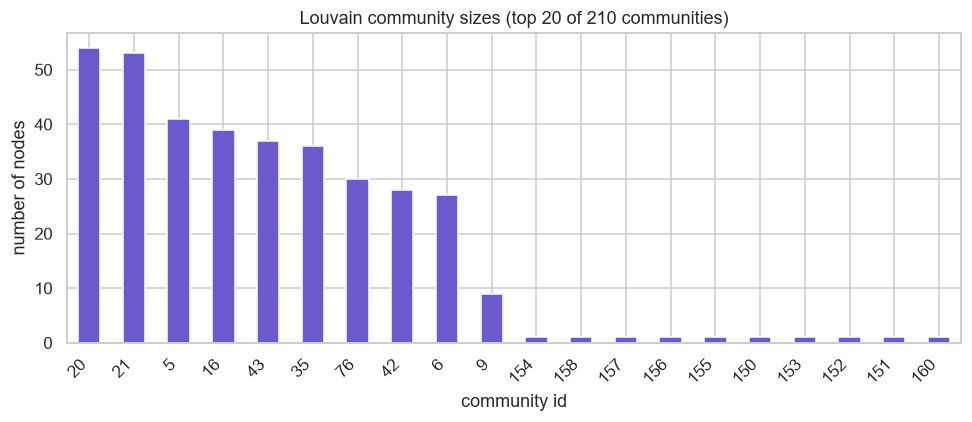

Total communities: 210
Communities with >= 5 nodes: 10
Singleton communities (1 node): 200
Community 20 (54 nodes): Belisce, Bilje, Bizovac, Bjelovar, Bosnjaci (+49 more)
Community 21 (53 nodes): Bakar, Bilice, Blato, Dicmo, Drnis (+48 more)
Community 5 (41 nodes): Bale - Valle, Barban, Barilovic, Baska Voda, Biograd na Moru (+36 more)
Community 16 (39 nodes): Beli Manastir, Benkovac, Beretinec, Bibinje, Bosiljevo (+34 more)
Community 43 (37 nodes): Buzet, Cavle, County od Dubrovnik-Neretva, Draganic, Draz (+32 more)
Community 35 (36 nodes): Cabar, Cacinci, Cazma, Delnice, Fuzine (+31 more)
Community 76 (30 nodes): Brdovec, Brinje, Brod Moravice, Donja Voca, Donji Lapac (+25 more)
Community 42 (28 nodes): Bol, Brela, Cerovlje, Cista Provo, Duga Resa (+23 more)
Community 6 (27 nodes): Baska, Buje - Buie, Cres, Dugopolje, Fazana - Fasana (+22 more)
Community 9 (9 nodes): Bedenica, Lekenik, Lovas, Marija Bistrica, Nijemci (+4 more)
Community 154 (1 nodes): Pojezerje
Community 158 (1 nodes

In [3]:
sizes = df['community'].value_counts().sort_values(ascending=False)
top_n = 20
top_sizes = sizes.head(top_n)

fig, ax = plt.subplots(figsize=(9, 4))
top_sizes.plot(kind='bar', ax=ax, color='slateblue')
ax.set_xlabel('community id')
ax.set_ylabel('number of nodes')
ax.set_title(f'Louvain community sizes (top {top_n} of {len(sizes)} communities)')
ax.set_xticklabels(top_sizes.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total communities: {len(sizes)}')
print(f'Communities with >= 5 nodes: {(sizes >= 5).sum()}')
print(f'Singleton communities (1 node): {(sizes == 1).sum()}')
sizes

for cid in top_sizes.index:
    members = df[df['community'] == cid]['region'].tolist()
    preview = ', '.join(members[:5])
    more = f' (+{len(members)-5} more)' if len(members) > 5 else ''
    print(f'Community {cid} ({len(members)} nodes): {preview}{more}')

### Eksterna validacija u odnosu na oznaku obalno/kontinentalno

In [4]:
nmi = cd.evaluate_against_coastal_label(df)
print('NMI (Louvain vs. coastal/continental label):', round(nmi, 4))

NMI (Louvain vs. coastal/continental label): 0.181




### Ručna unakrsna tabulacija (cross-tabulation)

NMI je jedan sažeti broj; unakrsna tabulacija u stilu matrice zabune (confusion-matrix), koja uspoređuje dodjelu zajednice s obalnom oznakom, je razumljivija i ovdje se računa izravno (a ne preko `src.community_detection`) kako bi se točno pokazalo koje su zajednice pretežno obalne, koje pretežno kontinentalne, a koje mješovite.

In [5]:
crosstab = pd.crosstab(df['community'], df['coastal'])
crosstab.columns = ['continental', 'coastal']
crosstab['purity'] = crosstab.max(axis=1) / crosstab.sum(axis=1)
crosstab.sort_values('purity', ascending=False)

,continental,coastal,purity
community,,,
0,1,0,1.000000
157,1,0,1.000000
133,1,0,1.000000
134,1,0,1.000000
135,1,0,1.000000
...,...,...,...
6,4,23,0.851852
35,27,9,0.750000
16,12,27,0.692308


## Visualize communities on the network

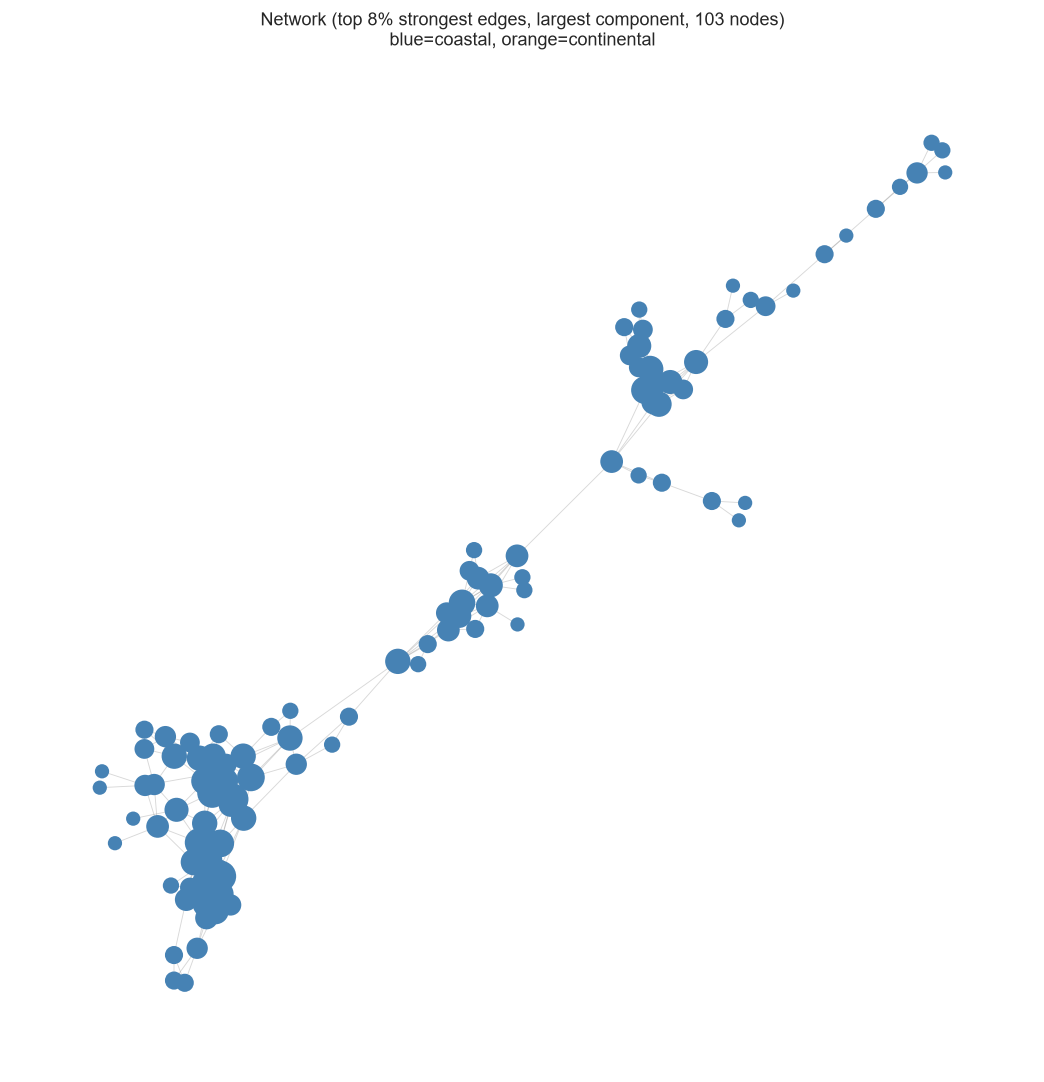

In [6]:
edge_weights = nx.get_edge_attributes(g, 'weight')
threshold = sorted(edge_weights.values(), reverse=True)[int(0.08 * len(edge_weights))]
strong_edges = [e for e, w in edge_weights.items() if w >= threshold]

sub_full = g.edge_subgraph(strong_edges).copy()
largest_cc = max(nx.connected_components(sub_full), key=len)
sub = sub_full.subgraph(largest_cc).copy()

coastal_flags = [sub.nodes[n].get('coastal') for n in sub.nodes()]
colors = ['steelblue' if c else 'darkorange' for c in coastal_flags]
degrees = dict(sub.degree(weight='weight'))
sizes = [60 + 350 * degrees[n] / max(degrees.values()) for n in sub.nodes()]

fig, ax = plt.subplots(figsize=(12, 12))
pos = nx.spring_layout(sub, weight='weight', seed=42, k=3.0 / max(1, sub.number_of_nodes()) ** 0.5, iterations=300)
nx.draw_networkx_edges(sub, pos, alpha=0.3, width=0.6, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(sub, pos, node_size=sizes, node_color=colors, ax=ax, linewidths=0)
ax.set_axis_off()
ax.set_title(f'Network (top 8% strongest edges, largest component, {sub.number_of_nodes()} nodes)\nblue=coastal, orange=continental')
plt.show()

### Osjetljivost na parametar rezolucije (resolution)

Louvainov parametar `resolution` određuje omjer broja i veličine otkrivenih zajednica. Ručno ga variramo i pratimo modularnost (Q) i NMI zajedno, jer samo maksimiziranje Q ne jamči najbolje poklapanje s eksternom (stvarnom) oznakom.

In [7]:
results = []
for res in (0.5, 0.75, 1.0, 1.25, 1.5, 2.0):
    p = cd.louvain_partition(g, resolution=res)
    f = cd.partition_to_frame(g, p)
    results.append({
        'resolution': res,
        'n_communities': f['community'].nunique(),
        'modularity': cd.modularity(g, p),
        'nmi_vs_coastal': cd.evaluate_against_coastal_label(f),
    })
sweep_df = pd.DataFrame(results)
sweep_df

,resolution,n_communities,modularity,nmi_vs_coastal
0,0.50,224,0.626421,0.187870
1,0.75,208,0.697960,0.192566
2,1.00,210,0.696896,0.181047
3,1.25,211,0.694219,0.181989
4,1.50,213,0.688754,0.180782
5,2.00,214,0.683685,0.181182


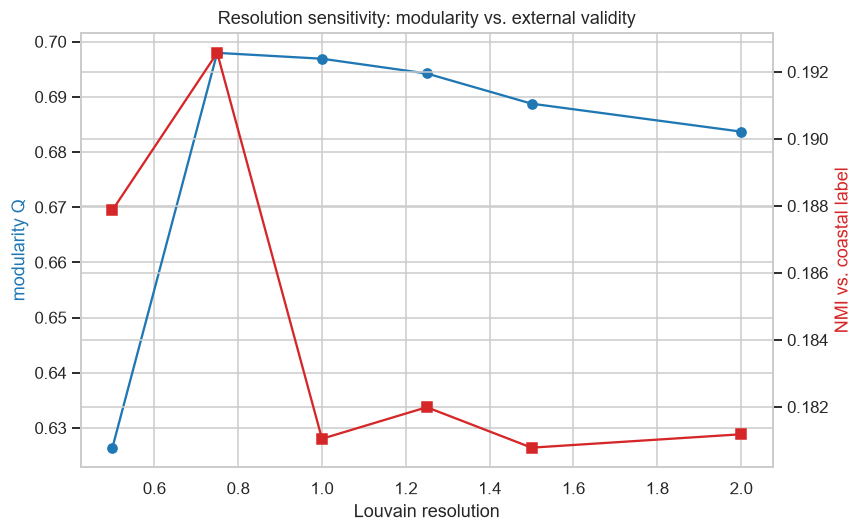

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(sweep_df['resolution'], sweep_df['modularity'], marker='o', color='tab:blue', label='modularity')
ax1.set_xlabel('Louvain resolution')
ax1.set_ylabel('modularity Q', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(sweep_df['resolution'], sweep_df['nmi_vs_coastal'], marker='s', color='tab:red', label='NMI vs coastal')
ax2.set_ylabel('NMI vs. coastal label', color='tab:red')
ax1.set_title('Resolution sensitivity: modularity vs. external validity')
plt.tight_layout()
plt.show()

### Usporedba s Girvan-Newman algoritmom

Girvan-Newman se pokreće s ciljem da pronađe isti broj zajednica kao Louvain s default rezolucijom, kako bi se napravila izravna usporedba "jabuka s jabukom" između brze aglomerativne heuristike i sporije, egzaktne divizivne metode.

In [ ]:
gn_partition = cd.girvan_newman_partition(g, n_communities=df['community'].nunique())
gn_df = cd.partition_to_frame(g, gn_partition)
print('Girvan-Newman modularity:', round(cd.modularity(g, gn_partition), 4))
print('Girvan-Newman NMI vs coastal label:', round(cd.evaluate_against_coastal_label(gn_df), 4))

In [ ]:
comparison = pd.DataFrame({
    'algorithm': ['Louvain', 'Girvan-Newman'],
    'modularity': [q, cd.modularity(g, gn_partition)],
    'nmi_vs_coastal': [nmi, cd.evaluate_against_coastal_label(gn_df)],
    'n_communities': [df['community'].nunique(), gn_df['community'].nunique()],
})
comparison

### Interpretacija

- Pozitivna modularnost znatno iznad 0 (u literaturi se obično $Q > 0.3$ smatra "jakom" strukturom zajednica) pokazuje da mreža nije slučajno povezana — postoji stvarno grupiranje (clustering).
- Stupac čistoće u unakrsnoj tabulaciji (crosstab) pokazuje je li svaka otkrivena zajednica pretežno obalna, pretežno kontinentalna ili mješovita; visoka čistoća kroz većinu zajednica podupire hipotezu o sličnosti sezonalnosti.
- Slaganje između Louvaina i Girvan-Newmana (slična modularnost i NMI) je umirujuće — znači da struktura zajednica nije artefakt pristranosti jednog konkretnog algoritma.